# 01 - Casting Defect EDA

주조 제품 비전 검사 데이터(`ravirajsinh45/real-life-industrial-dataset-of-casting-product`)에 대한 탐색.

- 클래스: `ok_front` (양품) vs `def_front` (불량)
- 이미지: 300x300 grayscale (학습 시 224x224 RGB 복제)
- 산출물은 `reports/figures/eda_*.png`에 저장됩니다.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from src import config
from src.utils import find_data_root
from src.dataset import gather_splits, CLASS_TO_IDX, IDX_TO_CLASS

sns.set_style('whitegrid')
config.ensure_dirs()
print('root:', ROOT)

root: C:\Users\User\Documents\MyProject\Newworld


## 1. 데이터 로드 및 분할 통계

In [2]:
train_s, val_s, test_s = gather_splits()

rows = []
for name, samples in [('train', train_s), ('val', val_s), ('test', test_s)]:
    labels = np.array([s.label for s in samples])
    rows.append({
        'split': name,
        'total': len(samples),
        'ok_front': int((labels == 0).sum()),
        'def_front': int((labels == 1).sum()),
        'defect_ratio': float((labels == 1).mean()),
    })
df_split = pd.DataFrame(rows)
df_split

,split,total,ok_front,def_front,defect_ratio
0,train,5638,2444,3194,0.566513
1,val,995,431,564,0.566834
2,test,715,262,453,0.633566


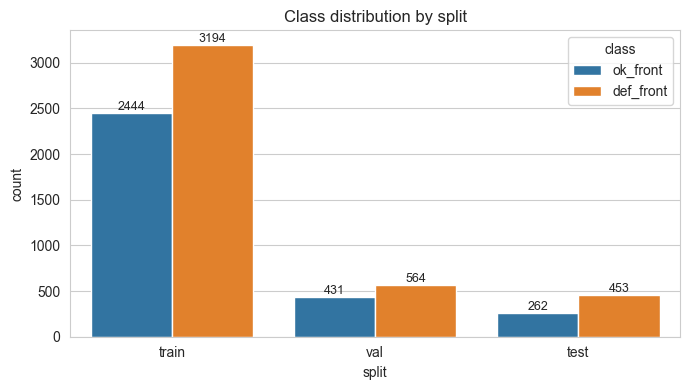

defect_ratio (train): 0.5665


In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
df_plot = df_split.melt(id_vars='split', value_vars=['ok_front', 'def_front'], var_name='class', value_name='count')
sns.barplot(data=df_plot, x='split', y='count', hue='class', ax=ax)
ax.set_title('Class distribution by split')
for container in ax.containers:
    ax.bar_label(container, fontsize=9)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / 'eda_class_distribution.png', dpi=140)
plt.show()
print('defect_ratio (train):', round(df_split.loc[df_split.split=='train','defect_ratio'].iloc[0], 4))

**관찰**: 불량(def_front) 비율이 약 57% 수준으로, 일반 이상탐지 데이터와 달리 다수 클래스가 불량입니다. 따라서 *불량 놓침(False Negative) 최소화*가 핵심 KPI가 됩니다.

## 2. 이미지 통계 (크기, 채널, 픽셀)

In [4]:
rng = np.random.default_rng(0)
sample_paths = [s.path for s in train_s]
idx = rng.choice(len(sample_paths), size=min(400, len(sample_paths)), replace=False)
subset = [sample_paths[i] for i in idx]
subset_labels = [train_s[i].label for i in idx]

stats = []
for p, lbl in zip(subset, subset_labels):
    with Image.open(p) as im:
        arr = np.asarray(im.convert('L'), dtype=np.float32)
    stats.append({
        'class': IDX_TO_CLASS[lbl],
        'width': im.size[0],
        'height': im.size[1],
        'mean': float(arr.mean()),
        'std': float(arr.std()),
    })
df_stats = pd.DataFrame(stats)
df_stats.describe()

,width,height,mean,std
count,400.0,400.0,400.000000,400.000000
mean,300.0,300.0,143.380312,59.934545
std,0.0,0.0,7.993726,3.406597
min,300.0,300.0,125.908112,51.474026
25%,300.0,300.0,137.541653,57.956413
50%,300.0,300.0,141.745644,60.161430
75%,300.0,300.0,151.470367,61.944188
max,300.0,300.0,158.730972,66.895309


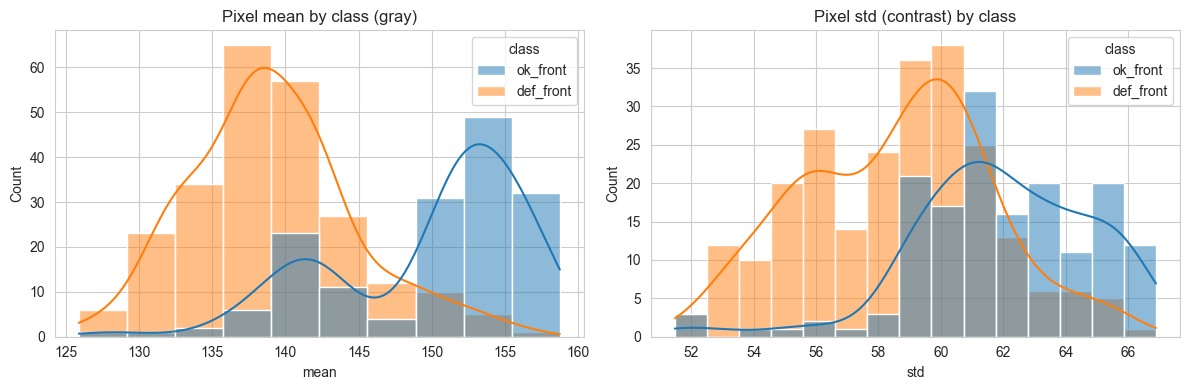

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df_stats, x='mean', hue='class', kde=True, ax=axes[0])
axes[0].set_title('Pixel mean by class (gray)')
sns.histplot(data=df_stats, x='std', hue='class', kde=True, ax=axes[1])
axes[1].set_title('Pixel std (contrast) by class')
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / 'eda_pixel_stats.png', dpi=140)
plt.show()

## 3. 클래스별 샘플 그리드

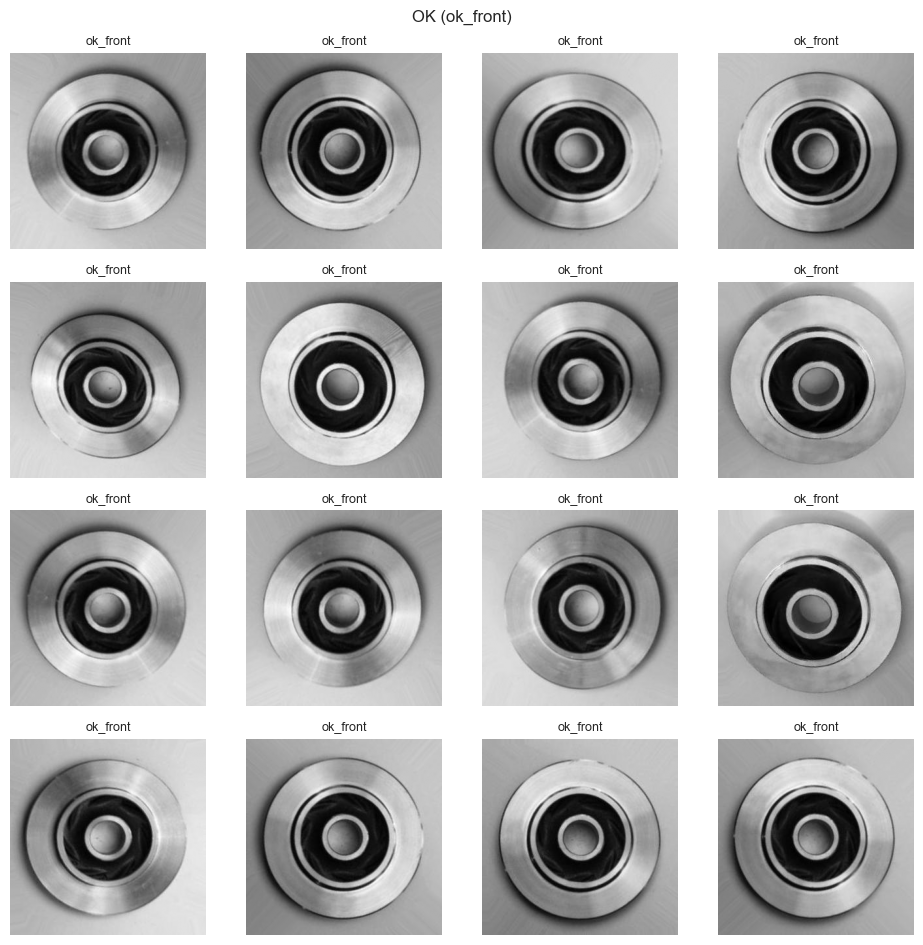

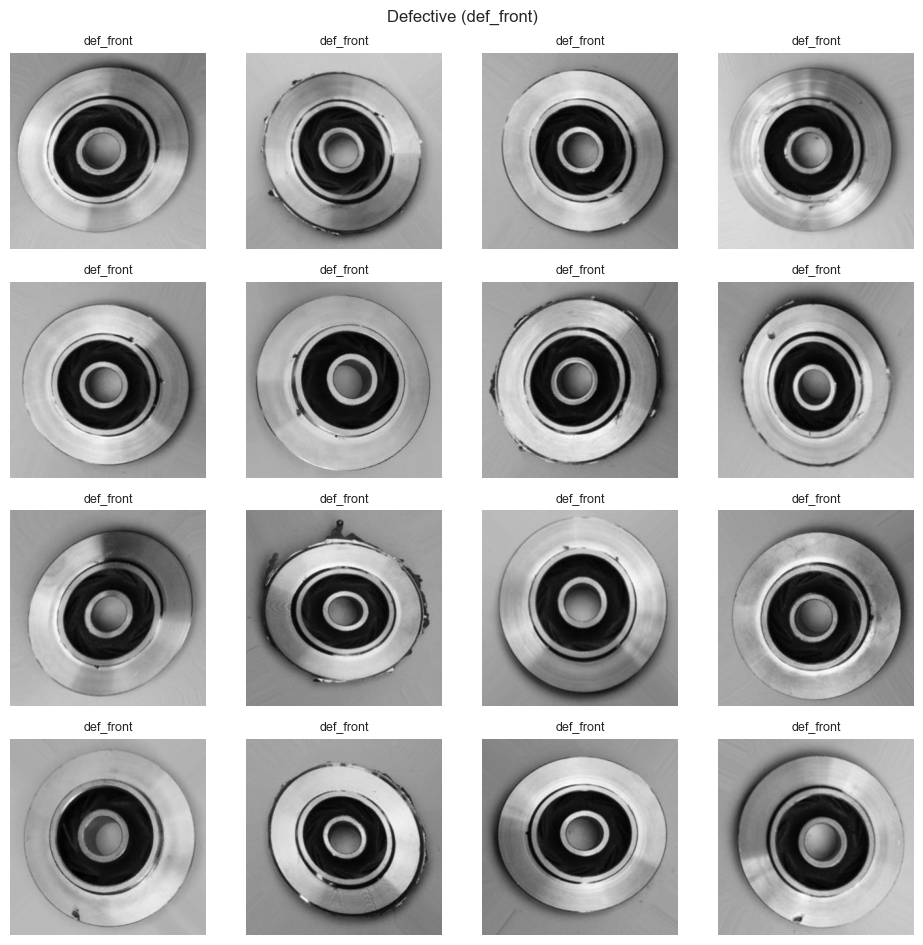

In [6]:
def show_grid(samples, n=16, title='samples', fname=None):
    sel = rng.choice(len(samples), size=min(n, len(samples)), replace=False)
    cols = 4
    rows = int(np.ceil(len(sel) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.4, rows * 2.4))
    for ax, i in zip(axes.flat, sel):
        s = samples[i]
        with Image.open(s.path) as im:
            ax.imshow(np.asarray(im.convert('L')), cmap='gray')
        ax.set_title(IDX_TO_CLASS[s.label], fontsize=9)
        ax.axis('off')
    for ax in axes.flat[len(sel):]:
        ax.axis('off')
    fig.suptitle(title)
    fig.tight_layout()
    if fname:
        fig.savefig(config.FIGURES_DIR / fname, dpi=140)
    plt.show()

ok_samples = [s for s in train_s if s.label == 0]
def_samples = [s for s in train_s if s.label == 1]
show_grid(ok_samples, n=16, title='OK (ok_front)', fname='eda_grid_ok.png')
show_grid(def_samples, n=16, title='Defective (def_front)', fname='eda_grid_def.png')

## 4. 클래스 평균 / 차분 이미지

두 클래스의 평균 이미지를 비교해 결함의 시각적 시그니처가 어디에 분포하는지 확인합니다.

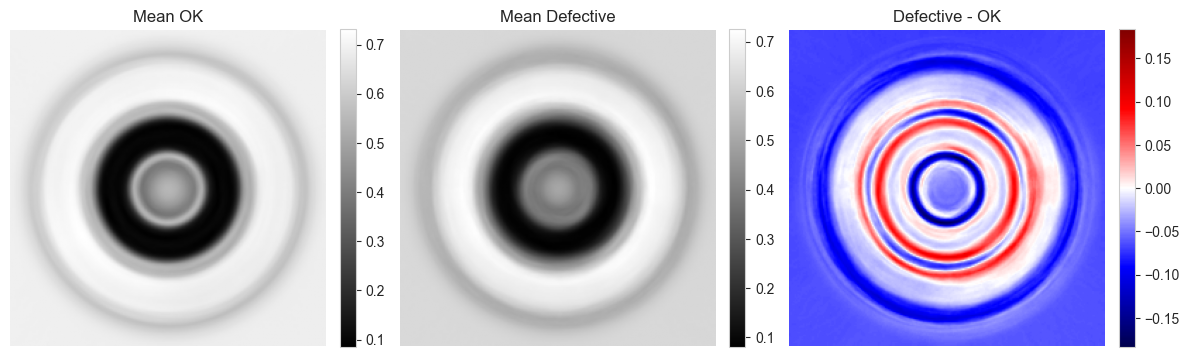

In [7]:
def mean_image(samples, n=300, size=(224, 224)):
    sel = rng.choice(len(samples), size=min(n, len(samples)), replace=False)
    acc = np.zeros(size, dtype=np.float64)
    for i in sel:
        with Image.open(samples[i].path) as im:
            arr = np.asarray(im.convert('L').resize(size), dtype=np.float64) / 255.0
        acc += arr
    return acc / len(sel)

mean_ok = mean_image(ok_samples)
mean_def = mean_image(def_samples)
diff = mean_def - mean_ok

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, t, cmap in zip(
    axes,
    [mean_ok, mean_def, diff],
    ['Mean OK', 'Mean Defective', 'Defective - OK'],
    ['gray', 'gray', 'seismic'],
):
    if cmap == 'seismic':
        v = float(np.abs(img).max())
        im = ax.imshow(img, cmap=cmap, vmin=-v, vmax=v)
    else:
        im = ax.imshow(img, cmap=cmap)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(t)
    ax.axis('off')
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / 'eda_mean_diff.png', dpi=140)
plt.show()

**관찰**: 차분(Defective - OK) 이미지에서 강도 차이가 균일하지 않은 영역들은 모델이 주목해야 할 결함 후보 영역입니다. 평균 이미지가 클래스 간 거의 동일하다는 점은, 단순 픽셀 통계만으로는 분류가 어렵고 **국지적 텍스처/패턴**이 핵심임을 시사합니다.

## 5. 잠재적 데이터 누수 점검 (파일명 패턴)

In [8]:
import re
from collections import Counter

def prefix(p):
    m = re.match(r'([a-zA-Z_]+)', p.name)
    return m.group(1) if m else p.name

ok_prefixes = Counter(prefix(s.path) for s in ok_samples)
def_prefixes = Counter(prefix(s.path) for s in def_samples)
print('OK prefixes:', ok_prefixes.most_common(5))
print('DEF prefixes:', def_prefixes.most_common(5))

OK prefixes: [('cast_ok_', 2444)]
DEF prefixes: [('cast_def_', 3194)]


**관찰**: 파일명 prefix가 클래스와 강한 상관이 있다면 모델이 파일명 노출 정보를 학습하지 못하도록 해야 합니다. 현재 파이프라인은 이미지 픽셀만 사용하므로 누수 위험은 없습니다.

## 요약 (EDA)
- 클래스 불균형은 모더리트 수준(~57%가 defect), 가중 샘플링/가중 손실로 처리.
- 픽셀 평균/표준편차 분포에서 클래스간 분리도가 약함 → CNN의 텍스처 학습 필요.
- 결함은 국지적 패턴 → Grad-CAM 해석 가치 큼.
- 파일명 누수는 픽셀-only 파이프라인으로 차단됨.